## Introduction

In this script we do some basic visualisation and dissolve the geometries of the wards. 

## Importing the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon

In [2]:
parent_dir = Path.cwd().parent
parent_dir

WindowsPath('C:/Ellen/personal/projects/geospatial/lst_bang_chennai/lstroad')

In [3]:
file_path_chennai = parent_dir / "data" / "processed"/ "chennai_fix_mapshaper.shp"

## Dissolve the wards

In [4]:
gdf_chennai = gpd.read_file(file_path_chennai)

In [5]:
print(f'There are  {gdf_chennai.shape[0]} wards in Chennai.')
print(f'There are  {gdf_chennai.shape[1]} columns in the dataset for Chennai.')

There are  200 wards in Chennai.
There are  4 columns in the dataset for Chennai.


In [6]:
gdf_chennai.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


<Axes: >

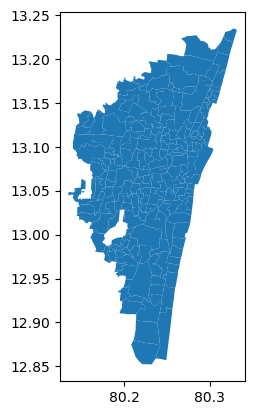

In [7]:
gdf_chennai.plot()

In [8]:
gdf_chennai.columns

Index(['Name', 'zone_id', 'zone_name', 'geometry'], dtype='object')

In [9]:
gdf_chennai_dissolved = gdf_chennai.dissolve()

<Axes: >

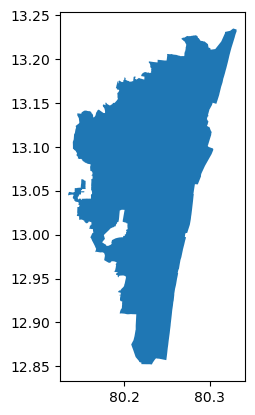

In [10]:
gdf_chennai_dissolved.plot()

This is a hole but that is because the empty area is not part of any ward but to have the overall area, we need to close the hole in order to compute the outer boundaries.

In [11]:
from shapely.geometry import Polygon, MultiPolygon

def close_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)

    elif geom.geom_type == "MultiPolygon":
        return MultiPolygon(
            [Polygon(p.exterior) for p in geom.geoms]
        )

    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

In [12]:
# I want to keep the original dissolved file and first create a copy
dissolved_chennai_copy = gdf_chennai_dissolved.copy()
dissolved_chennai_copy["geometry"] = dissolved_chennai_copy.geometry.apply(close_holes)

<Axes: >

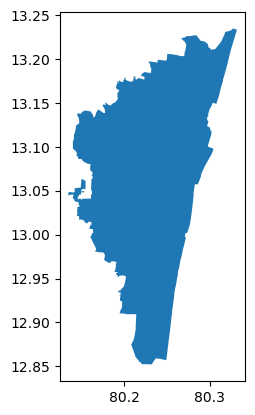

In [13]:
dissolved_chennai_copy.plot()

Save this shape file for later use (e.g. when extracting the road network).

In [15]:
dissolved_chennai_path = parent_dir / "data" / "processed"/ "chennai_dissolved.shp"
dissolved_chennai_copy.to_file(dissolved_chennai_path)

## Visualisation

In [19]:
# This reprojection is purely done for visualisation sake
# and position the shape of the labels
gdf_reproj = gdf_chennai.to_crs(epsg=3857)

In [20]:
# Path where to save the image:
path_figure = parent_dir / "images" / "chennai_wards.png"

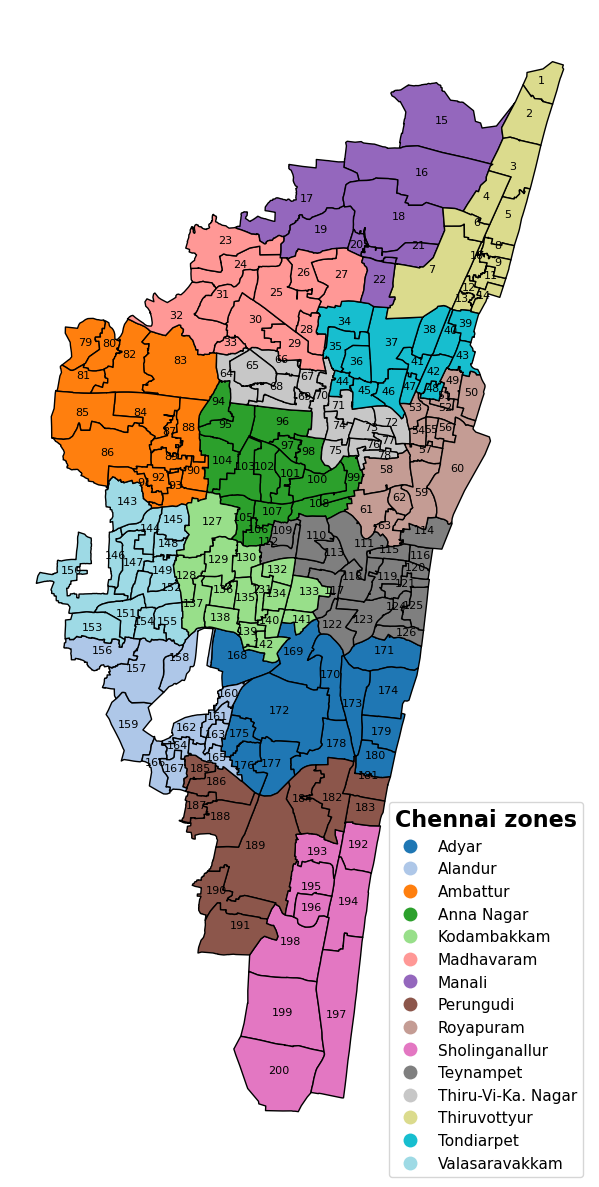

In [40]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(15,15)


gdf_reproj["label_point"] = gdf_reproj.geometry.representative_point()

legend_kwds={
    'loc' :'upper left',
    'bbox_to_anchor':(.64, .32),
    'fontsize':11,
    'frameon':True}

gdf_reproj.plot(
    ax=ax, 
    column = 'zone_name',
    categorical=True,
    cmap="tab20",
    linewidth=1,
    edgecolor='black',
    legend_kwds= legend_kwds,
    legend = True)

legend = ax.get_legend()

# Stackoverflow: 
# https://stackoverflow.com/questions/15637961/matplotlib-alignment-of-legend-title
legend.set_title("Chennai zones", prop={"size": 16, "weight": "bold"})
legend._legend_box.align = "left"
legend.get_title().set_ha("left")
legend.prop.set_size(14)

gdf_reproj["label_point"] = gdf_reproj.geometry.representative_point()


for _, row in gdf_reproj.iterrows():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row["Name"],
        fontsize=8,
        ha="center",
    )

ax.set_axis_off()

plt.savefig(path_figure, dpi=300, bbox_inches='tight')

plt.show()